#Similarity? Подобие?

Принцип схожих свойств (SPP) и соотношения структуры и активности (SAR).
Предположение:структурно схожие молекулы имеют схожие свойства и, следовательно, схожую биологическую активность.

Как использовать в виртуальном скрининге:

*   Input: набор молекул с известной аффинностью
*   Условие: аффинность зависит от структуры
*   Output: новые активные молекулы

Как оценить сходство молекул? Дескрипторы


*   1D дескрипторы (одно значение представляет всю молекулу): растворимость, logP, молекулярная масса
*   2D дескрипторы (детальное представление отдельных частей молекулы, **"отпечатки пальцев" молекулы**): молекулярные графы, пути, фрагменты, атомные окружения
*   3D дескрипторы 3D (пространственная структура)

Молекулярные отпечатки пальцев — это представление молекул (химические и молекулярные признаки) в форме битовых строк, битовых векторов или массивов. Каждый бит соответствует предопределенному молекулярному признаку или среде, где «1» представляет наличие, а «0» — отсутствие признака. Также возможен подсчет, как часто присутствует определенный признак.

Отпечатки пальцев Molecular ACCess System (MACCS): наличие или отсутствие фрагмента (из эмпирически подобранного набора 166 структурных фрагментов)

Отпечатки пальцев Моргана: количество соседних связей или атомов в пределах заданного радиуса

**Коэффициент Танимото
Коэффициент Сёренсена**

*Sydow, D., Rodríguez-Guerra, J. & Volkamer, A. Teaching Computer-Aided Drug Design Using TeachOpenCADD. ACS Symposium Series 135–158 (2021) doi:10.1021/bk-2021-1387.ch010.*

*Задание 1: Определить молекулярное подобие следующих соединений**

Соединения:

1.  **Doxycycline**


2.  **Amoxicilline**


3. **Furosemide**


4. **Glycol dilaurate**


5. **Tetracycline**




**Команды:**
1.  df = pd.DataFrame({"name": names, "smiles": smiles})
2. PandasTools.AddMoleculeColumnToFrame(molecules, "smiles")
3. molecules["MW"] = molecules["ROMol"].apply
4. maccs_fp = MACCSkeys.GenMACCSKeys(molecule)
5. maccs_fp.ToBitString()
6. molecules["maccs"] = molecules.ROMol.apply(MACCSkeys.GenMACCSKeys)
7. fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
7. molecules["morgan"] = molecules["ROMol"].map(fpg.GetFingerprint)
8. molecules["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
9. molecules["dice_maccs"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)


#Установка библиотек

In [ ]:
# Установка библиотеки rdkit
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 32.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import (
    PandasTools,
    Draw,
    Descriptors,
    MACCSkeys,
    rdFingerprintGenerator,
)

In [ ]:
names = ["m6A","Hesperidin", "Quercetin", "Kaempferol","Rutin"]
smiles = ["n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@H]3O)CO","O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C@H](O)[C@@H](O)[C@H]1O)C)[C@@H](O)[C@H](O)[C@H]2O)cc5O[C@H](c3ccc(OC)c(O)c3)C4", "O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O", "O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12", "CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(=C4C3=O)O)O)C5=CC(=C(C=C5)O)O)O)O)O)O)O)O"]

In [ ]:
molecules = pd.DataFrame({'name': names, 'smiles': smiles})

In [ ]:
PandasTools.AddMoleculeColumnToFrame(molecules, 'smiles')

In [ ]:
molecules['MW'] = molecules['ROMol'].apply(Descriptors.ExactMolWt)

,name,smiles,ROMol,MW
0,m6A,n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@...,,281.112404
1,Hesperidin,O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C...,,610.189770
2,Quercetin,O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O,,302.042653
3,Kaempferol,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,,286.047738
4,Rutin,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(...,,610.153385

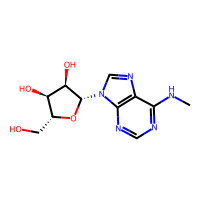
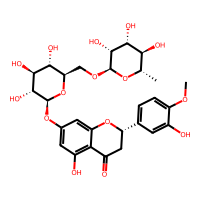
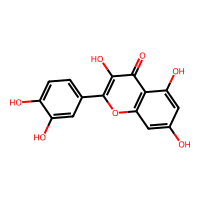
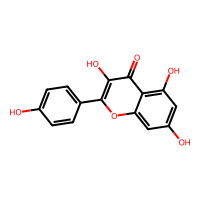
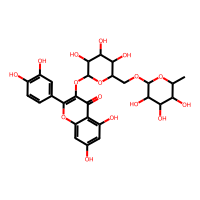

In [ ]:
molecules

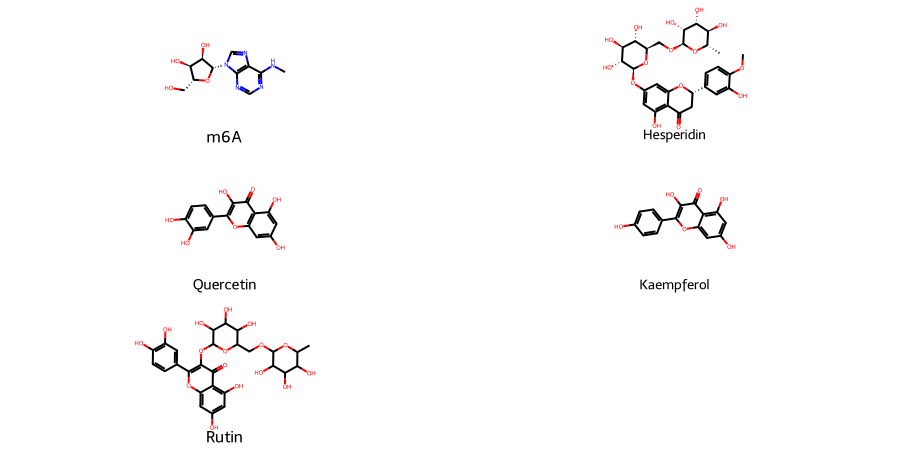

In [ ]:
Draw.MolsToGridImage(
  molecules["ROMol"].to_list(),
  molsPerRow=2,
  subImgSize=(450, 150),
  legends=molecules["name"].to_list(),
)

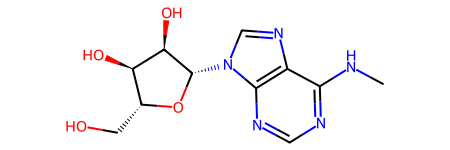

In [ ]:
molecule = molecules["ROMol"][0]
molecule

In [ ]:
maccs_fp = MACCSkeys.GenMACCSKeys(molecule)

In [ ]:
maccs_fp

In [ ]:
maccs_fp.ToBitString()

'00000000000000000000000000000000000000100000000000000110010000100100000010010101101101000111110111100100010001100000010011100101000111010101101100101011110111111111110'

,name,smiles,ROMol,MW,maccs
0,m6A,n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@...,,281.112404,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Hesperidin,O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C...,,610.189770,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Quercetin,O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O,,302.042653,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Kaempferol,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,,286.047738,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Rutin,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(...,,610.153385,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

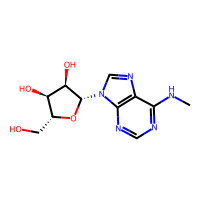
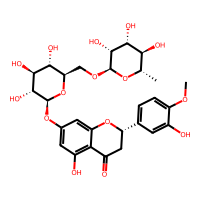
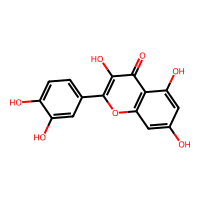
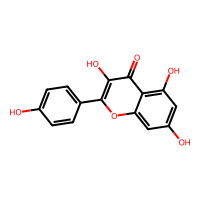
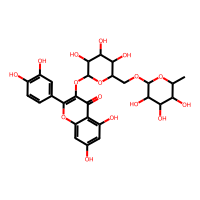

In [ ]:
molecules["maccs"] = molecules.ROMol.apply(MACCSkeys.GenMACCSKeys)
molecules

In [ ]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

,name,smiles,ROMol,MW,maccs,morgan
0,m6A,n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@...,,281.112404,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Hesperidin,O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C...,,610.189770,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Quercetin,O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O,,302.042653,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Kaempferol,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,,286.047738,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Rutin,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(...,,610.153385,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

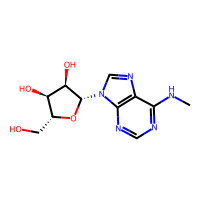
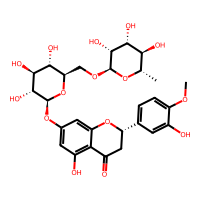
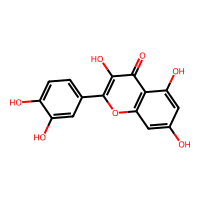
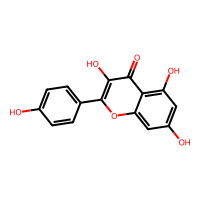
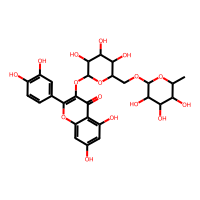

In [ ]:
molecules["morgan"] = molecules["ROMol"].map(fpg.GetFingerprint)
molecules

In [ ]:
molecule_query = molecules["maccs"][0]
molecule_list = molecules["maccs"].to_list()

molecules["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_maccs"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

In [ ]:
out = molecules.sort_values(["tanimoto_maccs"], ascending=False).reset_index()
out[["name", "MW", "tanimoto_maccs", "dice_maccs"]]

,name,MW,tanimoto_maccs,dice_maccs
0,m6A,281.112404,1.000000,1.000000
1,Hesperidin,610.189770,0.515152,0.680000
2,Rutin,610.153385,0.507692,0.673469
3,Quercetin,302.042653,0.396825,0.568182
4,Kaempferol,286.047738,0.380952,0.551724


,name,smiles,ROMol,MW,maccs,morgan,tanimoto_maccs,dice_maccs
0,m6A,n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@...,,281.112404,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.000000,1.000000
1,Hesperidin,O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C...,,610.189770,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.515152,0.680000
2,Quercetin,O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O,,302.042653,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.396825,0.568182
3,Kaempferol,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,,286.047738,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.380952,0.551724
4,Rutin,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(...,,610.153385,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.507692,0.673469

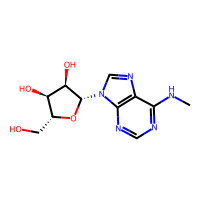
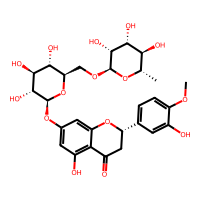
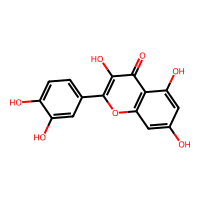
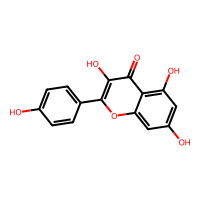
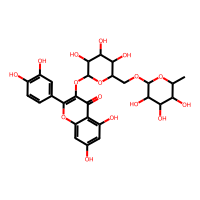

In [ ]:
molecules

In [ ]:
molecule_query_morgan = molecules["morgan"][0]
molecule_list_morgan = molecules["morgan"].to_list()

molecules["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(molecule_query_morgan, molecule_list_morgan)
molecules["dice_morgan"] = DataStructs.BulkDiceSimilarity(molecule_query_morgan, molecule_list_morgan)

In [ ]:
out = molecules.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
out[["name", "MW", "tanimoto_morgan", "dice_morgan"]]

,name,MW,tanimoto_morgan,dice_morgan
0,m6A,281.112404,1.000000,1.000000
1,Rutin,610.153385,0.157303,0.271845
2,Hesperidin,610.189770,0.136842,0.240741
3,Kaempferol,286.047738,0.072464,0.135135
4,Quercetin,302.042653,0.070423,0.131579


,name,smiles,ROMol,MW,maccs,morgan,tanimoto_maccs,dice_maccs,tanimoto_morgan,dice_morgan
0,m6A,n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@...,,281.112404,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.000000,1.000000,1.000000,1.000000
1,Hesperidin,O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C...,,610.189770,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.515152,0.680000,0.136842,0.240741
2,Quercetin,O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O,,302.042653,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.396825,0.568182,0.070423,0.131579
3,Kaempferol,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,,286.047738,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.380952,0.551724,0.072464,0.135135
4,Rutin,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(...,,610.153385,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.507692,0.673469,0.157303,0.271845

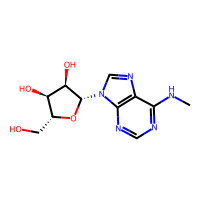
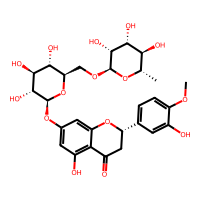
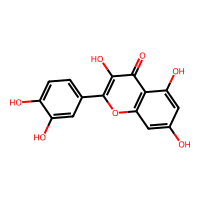
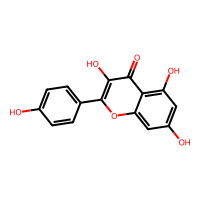
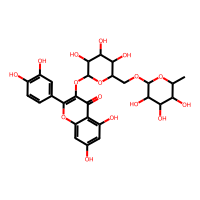

In [ ]:
molecules

In [ ]:
out = molecules.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
out[["name", "MW", "tanimoto_maccs", "dice_maccs", "tanimoto_morgan", "dice_morgan"]]

,name,MW,tanimoto_maccs,dice_maccs,tanimoto_morgan,dice_morgan
0,m6A,281.112404,1.000000,1.000000,1.000000,1.000000
1,Rutin,610.153385,0.507692,0.673469,0.157303,0.271845
2,Hesperidin,610.189770,0.515152,0.680000,0.136842,0.240741
3,Kaempferol,286.047738,0.380952,0.551724,0.072464,0.135135
4,Quercetin,302.042653,0.396825,0.568182,0.070423,0.131579
